# Information Extraction - Exploratory Notebook
## Purpose
The main purpose of this notebook is to explore how different approaches perform at populating missing data within a structured dataset, based on a column of unstructured data.

---
---

## Contents of this notebook...
##### 1. Import main packages and dataset.
##### 2. Standardise and re-map Vict-Offender Relationship column.
##### 3. Clean the unstructured text in the CRIME NOTES column.


---
---

## Step 1: Import packages and dataset
In this step, we want to import the packages we'll be working with. We can always add more packages as we need them, so the following will be just what we need to import and view the data in tabular form. 

In [7]:
# Before we import our packages, we need to have the installed on our local machine. Use a combinaion of pip and the requirements.txt file for this.
# note, remove the -q flag to increase verbosity. 
!pip install -q -r requirements.txt

You should consider upgrading via the '/Users/sbrv951/Documents/CodeLibrary/MissingDataPredictor/venv/bin/python3 -m pip install --upgrade pip' command.


In [3]:
# import packages into our python environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# with pandas installed, we can now read and visualise the data in tab format.
data = pd.read_csv('crime_data.csv')
data.head()

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_56170/1314682263.py:2: DtypeWarning: Columns (16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('crime_data.csv')


,Unnamed: 0,CRIME REF,DATE EARLIEST COMMITTED,DATE LATEST COMMITTED,DATE FIRST CRIMED,Reclassification,OFFENCE FORMER HO CODE,OFFENCE RECORDED HO CODE,CRIMSEC3 CATEGORY RECORDED,OFFENCE RECORDED GROUP,...,IND ALCOHOL,IND DOMESTIC,IND DRUGS,IND KNIFE INVOLVED,IND GUN INVOLVED,DISPOSAL TEXT,EVENT TYPE,Any Arrest,Risk,CRIME NOTES
0,NaN,516162841.0,30/04/2016 17:52:00,01/05/2016 17:52:00,18/07/2016 17:53:46,NaN,2811.0,2811.0,BURGLARY,Burglary Dwelling,...,N,Y,N,N,N,"15: CPS - NAMED SUSPECT, VICTIM SUPPORTS BUT E...",Domestic abuse - without children,N,DA risk-Bronze,"THE VICTIM AND SUSPECT ARE BROTHER AND SISTER,..."
1,NaN,512097868.0,19/06/2012 03:30:00,19/06/2012 03:30:00,28/11/2016 12:47:24,NaN,5800.0,5800.0,CRIMINAL DAMAGE,Criminal Damage excluding Arson,...,Y,Y,N,N,N,"15: CPS - NAMED SUSPECT, VICTIM SUPPORTS BUT E...",Criminal damage,Y,NaN,NaN
2,NaN,517121100.0,17/05/2017 14:00:00,17/05/2017 14:00:00,17/05/2017 19:24:57,Y,10501.0,806.0,VIOLENCE,Violence With Injury,...,N,Y,N,N,N,16: VICTIM DECLINES/WITHDRAWS SUPPORT - NAMED ...,Violence against the person,N,NaN,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...
3,NaN,517121132.0,16/05/2017 22:00:00,17/05/2017 09:00:00,18/05/2017 15:30:33,NaN,5803.0,5803.0,CRIMINAL DAMAGE,Criminal Damage excluding Arson,...,N,Y,N,N,N,16: VICTIM DECLINES/WITHDRAWS SUPPORT - NAMED ...,Domestic abuse - with children,N,DA risk-Bronze,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...
4,NaN,517137157.0,04/06/2017 06:40:00,04/06/2017 06:40:00,04/06/2017 10:29:01,NaN,801.0,801.0,VIOLENCE,Violence With Injury,...,Y,Y,Y,N,N,1: CHARGED,Violence against the person,Y,NaN,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...


In [5]:
# we can also collect some basic information about our dataset
column_names = [col.title() for col in data.columns]

print(f'The dataset has {len(data.columns)} columns, and {len(data)} rows.')
print('--------')
print('COLUMN NAMES:')
for col in column_names:
    print(col)


The dataset has 32 columns, and 19014 rows.
--------
COLUMN NAMES:
Unnamed: 0
Crime Ref
Date Earliest Committed
Date Latest Committed
Date First Crimed
Reclassification
Offence Former Ho Code
Offence Recorded Ho Code
Crimsec3 Category Recorded
Offence Recorded Group
Offence Recorded
Ind Recorded Crime
V Nominal Ref
Victim Crime Age
Victim Gender
V Ethnic Self
O Nominal Ref
O Offender Crime Age
O Offender Gender
O Ethnic Self
O Ind Arrested
Vic Offender Relationship
Ind Alcohol
Ind Domestic
Ind Drugs
Ind Knife Involved
Ind Gun Involved
Disposal Text
Event Type
Any Arrest
Risk
Crime Notes


## Step 2: Standardising and re-mapping Vict-Offender Relationship column
Next, we need to clean and standardise the data so that it's in a format that our algorithms' expect. In this step, we remap the large number of values in the VIC OFFENDER RELATIONSHIP column to a smaller number of categories

In [6]:
# filter the dataframe to include only the columns we're interested in
cols = [
    'VIC OFFENDER RELATIONSHIP',
    'CRIME NOTES'
]


data_f = data[cols]
data_f.head(10)

,VIC OFFENDER RELATIONSHIP,CRIME NOTES
0,NaN,"THE VICTIM AND SUSPECT ARE BROTHER AND SISTER,..."
1,NaN,NaN
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...
6,OTHER,HAPPENED 06/07/16 APPROX 0600 HOURS ON THE INF...
7,BOYFRIEND/GIRLFRIEND,FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...
8,EX PARTNER,POLICE CALLED TO VERBAL ONLY DOMESTIC. UPON HA...
9,BOYFRIEND/GIRLFRIEND,"B173***SEC 39 ASSAULT, THREATS TO KILL. DOMEST..."


In [7]:
# next, it seems that we have different data types within each column (see NaN).
from collections import Counter

data_types_col1 = []

for dt in data_f['VIC OFFENDER RELATIONSHIP']:
    data_types_col1.append(type(dt))

print('Data types in Column 1')
print(Counter(data_types_col1))

# we can also see how many NaNs are in column 2
data_types_col2 = []

for dt in data_f['CRIME NOTES']:
    data_types_col2.append(type(dt))

print('Data types in Column 2')
print(Counter(data_types_col2))


Data types in Column 1
Counter({<class 'str'>: 14119, <class 'float'>: 4895})
Data types in Column 2
Counter({<class 'str'>: 18794, <class 'float'>: 220})


In [8]:
# before filtering the data, we should take a look at what the NaNs look like
data_f[data_f['CRIME NOTES'].apply(lambda x: isinstance(x, float))].head(20)

,VIC OFFENDER RELATIONSHIP,CRIME NOTES
1,NaN,NaN
34,NaN,NaN
78,NaN,NaN
101,NaN,NaN
305,BOYFRIEND/GIRLFRIEND,NaN
360,NaN,NaN
375,NaN,NaN
383,NaN,NaN
419,SPOUSE/DEFACTO,NaN
425,NaN,NaN


We expect that our columns, VIC OFFENDER RELATIONSHIP and CRIME NOTES, contain text ('str' in Python). Therefore, it seems that column 1 has 4895 missing values, while column 2 has 220 missing values.

Consequently, rows where Column 1 (VIC OFFEDER RELATIONSHIP) are empty cannot be used to train the model. They could instead serve as an unlabelled dataset, and could be a recipient of our best performing model. By contrast, the 220 rows where col2 (CRIME NOTES) is empty cannot be used and should be deleted.

In [9]:
# remove rows where CRIME NOTES is empty
data_f2 = data_f.dropna(subset=['CRIME NOTES'])
print(f'Row count of original dataset: {len(data_f)}')
print(f'Row count of filered dataset: {len(data_f2)}')
print(f'Difference in row count between original and filtered dataset: {len(data_f)-len(data_f2)}')

Row count of original dataset: 19014
Row count of filered dataset: 18794
Difference in row count between original and filtered dataset: 220


In [10]:
# separate the rows where VIC OFFENDER RELATIONSHIP is empty and store that as an unlabelled dataset.
unlabelled_data = data_f2[data_f2['VIC OFFENDER RELATIONSHIP'].isna()]
unlabelled_data.head(10)

,VIC OFFENDER RELATIONSHIP,CRIME NOTES
0,NaN,"THE VICTIM AND SUSPECT ARE BROTHER AND SISTER,..."
19,NaN,"RESTRAINING ORDER IN PLACE, FORBIDDING CONTACT..."
27,NaN,VICTIM HAD AN ARGUMENT WITH HER PARTNER EARLIE...
30,NaN,MALE OFFENDER TEXTS EX FEMALE PARTNER AND IN D...
36,NaN,MIDWEEK. NIGHT TIME. DOMESTIC INCIDENT. OFFEND...
43,NaN,MALE OFFENDER ATTENDS EX PARTNER'S HOME ADDRES...
49,NaN,IP AND DP ARE CURRENT PARTNERS AND AN ARGUMENT...
55,NaN,AGG RETURNED TO HER HOME ADDRESS AFTER DROPPIN...
56,NaN,"APPROXIMATELY 5-6 WEEKS AGO, SCOTT WAS WITHIN ..."
57,NaN,"SUSPECT ATTENDS IPS HOME ADDRESS,DRUNK,BANGS O..."


In [11]:
# we also need to drop the remaining NaNs from the filtered dataset to make sure we aren't training/testing using them.
data_f3 = data_f2.dropna()

# the difference after this adjustment should match the number of NaNs in the VIC OFFENDER RELATIONSHIP
count_na = len(data_f2[data_f2['VIC OFFENDER RELATIONSHIP'].isna()])
print(f'Rows in original filtered dataset: {len(data_f2)}')
print(f'Count of NaNs in the VIC OFFENDER RELATIONSHIP column: {count_na}')
print(f'Count of rows in original filtered dataset minus NaNs: {len(data_f2)-count_na}')

print(f'Rows in filtered train/test dataset: {len(data_f3)}')

Rows in original filtered dataset: 18794
Count of NaNs in the VIC OFFENDER RELATIONSHIP column: 4713
Count of rows in original filtered dataset minus NaNs: 14081
Rows in filtered train/test dataset: 14081


As the number of rows in the train/test set matches the originally filtered dataset minus NaNs, we can proceed.

The next step involves cleaning and standardising the text in the two columns. We can start by looking at all the possible values in VIC OFFENDER RELATIONSHIP column.

In [12]:
# print the set of values in the VIC OFFENDER RELATIONSHIP column
vic_off_relationship_vals = []

for element in data_f3['VIC OFFENDER RELATIONSHIP']:
    vic_off_relationship_vals.append(element)

# convert list to a Counter object
vic_off_counter = Counter(vic_off_relationship_vals)

# print the total number of keys in the data
print(f'Total number of keys in the dataset: {len(vic_off_counter)}')

# print each type of relationship and their counts in the dataset
for key, value in vic_off_counter.items():
    print(key)

Total number of keys in the dataset: 56
BOYFRIEND/GIRLFRIEND
EX PARTNER
OTHER
PARENT OF OFFENDER
SPOUSE/DEFACTO
SIBLING OF OFFENDER
OTHER FAMILY MEMBER
STRANGER
ACQUAINTANCE
CHILD OF OFFENDER
VICTIMLESS/CRIME AGAINST STATE
BOYFRIEND/GIRLFRIEND ACQUAINTANCE
EX PARTNER BOYFRIEND/GIRLFRIEND
EX PARTNER NEIGHBOUR
EX PARTNER OTHER FAMILY MEMBER
EX PARTNER OTHER FAMILY MEMBER ACQUAINTANCE
NEIGHBOUR
NOT SEEN
EX PARTNER CHILD OF OFFENDER
EX PARTNER ACQUAINTANCE
EX PARTNER BOYFRIEND/GIRLFRIEND ACQUAINTANCE
EX PARTNER OTHER FAMILY MEMBER SIBLING OF OFFENDER PARENT OF OFFENDER
OTHER FAMILY MEMBER CHILD OF OFFENDER OTHER
SPOUSE/DEFACTO BOYFRIEND/GIRLFRIEND
EX PARTNER SPOUSE/DEFACTO
OTHER FAMILY MEMBER CHILD OF OFFENDER
VICTIM REFUSES TO IDENTIFY
SIBLING OF OFFENDER BOYFRIEND/GIRLFRIEND
SIBLING OF OFFENDER CHILD OF OFFENDER
PARENT OF OFFENDER OTHER
SIBLING OF OFFENDER PARENT OF OFFENDER
OTHER FAMILY MEMBER ACQUAINTANCE
ACQUAINTANCE OTHER
ACQUAINTANCE NEIGHBOUR
EX PARTNER OTHER
STRANGER NOT SEEN
OTHE

In [13]:
# use the vic_offender_remapping.csv file to map exiting categories to new ones
mapping_df = pd.read_csv('vic_offender_remapping.csv', delimiter=',')
mapping_df.columns = mapping_df.columns.str.strip()
mapping_df.head()

,value,mapping
0,BOYFRIEND/GIRLFRIEND,partner
1,EX PARTNER,ex_partner
2,OTHER,other
3,PARENT OF OFFENDER,parent
4,SPOUSE/DEFACTO,partner


In [14]:
# map the values in the VIC OFFENDER COLUMN to the corresponding values in the mapping DF
data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])
data_f3.head()


/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_56170/799189852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])


,VIC OFFENDER RELATIONSHIP,CRIME NOTES,remapped_cats
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...,partner
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...,ex_partner
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...,partner
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...,ex_partner
6,OTHER,HAPPENED 06/07/16 APPROX 0600 HOURS ON THE INF...,other


# export the filtered dataset (for review)
data_f3.to_csv('')

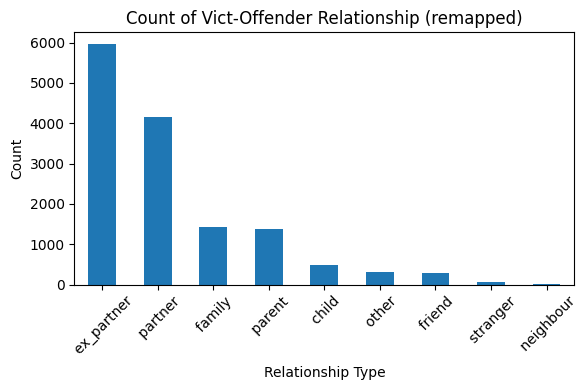

In [15]:
# we can now visualise a count of each type of relationship the remapped column
remapped_cats_counts = data_f3['remapped_cats'].value_counts()

# we can then create a bar chart demonstrating the counts
plt.figure(figsize=(6,4))
remapped_cats_counts.plot(kind='bar')
plt.title('Count of Vict-Offender Relationship (remapped)')
plt.xlabel('Relationship Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.savefig('plots/v1_remapping_counts.png')
plt.show()

Based on the plot above, we see we have a diverse (9 classes) but imbalanced dataset. The most common classes are ex_partner (approx 6000) and partner (approx 4000) classes. Conversely, five of the classes (child, other, friend, stranger, and neighbour) have very few instances - they are rare events. This can be problematic for supervised ML models that require examples to train from - and will impact our overall performance. 

There are different ways to approach this problem - for now, we can just remove those classes with support less than a given threshold.

In [113]:
# remove classes with low support
# set a threshold, where classes with a count less than X are removed from the data
support_threshold = 100

# estimate the support for each class in the data
class_counts = data_f3['remapped_cats'].value_counts()

# specify the classes to remove
classes_to_remove = class_counts[class_counts < support_threshold].index

# filter the dataset
data_f4 = data_f3[~data_f3['remapped_cats'].isin(classes_to_remove)]

# check the filtered dataset
data_f4.shape

(14012, 3)

## Step 3: Clean the pre-process the unstructured text in the CRIME NOTES column.
In this step, we need to standardise and clean the unstructured text in the CRIME NOTES column. The steps used will largely depend on what type of features we want to use to train our model. To start with, we can start with something simple like TF-IDF (Term Frequency - Inverse Document Frequency).

In [114]:
# first, we should remind ourselves of what the CRIME NOTES column looks like.
data_f4['CRIME NOTES'].head(10)

2     MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...
3     THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...
4     KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...
5     SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...
6     HAPPENED 06/07/16 APPROX 0600 HOURS ON THE INF...
7     FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...
8     POLICE CALLED TO VERBAL ONLY DOMESTIC. UPON HA...
9     B173***SEC 39 ASSAULT, THREATS TO KILL. DOMEST...
10    B162 CRIME *** SECTIO 47 ASSAULT****GOLD DOMES...
11    REPORT FROM THIRD PARTY THAT SUSPECT HAS MADE ...
Name: CRIME NOTES, dtype: object

In [115]:
# we cna also look at a complete example of one of the rows
data_f4['CRIME NOTES'].iloc[10]

'CLAIRE AND SEAN WERE ARE NO LONGER IN A RELATIONSHIP HOWEVER THEY HAVE A CHILD TOGETHER. SEAN AGREED TO LOOK AFTER THE HOUSE DURING THE WEEK WHILE CLAIRE WENT AWAY WITH FRIENDS. WHEN SHE RETURNED THE HOUSE WAS A MESS AND SEAN HAD SOLD HER SKY BOX TO CASH CONVERTORS FOR CASH. THEY ARGUED SO CLAIRE LEFT. WHEN SHE RETURNED HOME SEAN HAD GONE. HOWEVER HE RANG HER SAYING HE WAS ON HIS WAY OVER TO SMASH ALL HER WINDOWS, A SHORT TIME LATER HE RETURNED TO HER ADDRESS. THEY BEGAN TO ARGUE AGAIN AND SEAN TOOK CLAIRE PHONE HE THEN PLACED HER IN A HEADLOCK AND PUNCHED HER SEVERAL TIMES TO THE LEFT SIDE OF HER FACE AND BACK OF HER HEAD. CLAIRE MANAGED TO BREAK FREE ND KNOCKED ON A NEIGHBOURS HOUSE TO ASK FOR HELP.SEAN THEN RAN AWAY. HE DID GIVE CLAIRE HER PHONE BACK PRIOR TO LEAVING'

In [117]:
# given that the text appears in upper casing, we should convert the text to lower casing as our algorithms will work better.
data_f4.loc[:, 'text_processed'] = data_f4['CRIME NOTES'].str.lower()

# we should also remove punctuation and numbers to reduce noise when training the model.
import re
data_f4.loc[:, 'text_processed'] = data_f4.loc[:, 'text_processed'].apply(lambda x: re.sub(r'[^\w\s]|(\d+)','', x))
data_f4['text_processed'].head()

2    mark pushes zoe to wake her up and this result...
3    third hand report of domestic assault patrol a...
4    known offender caused broken bones and facial ...
5    suspect has approached ex partner whilst her v...
6    happened  approx  hours on the informants stre...
Name: text_processed, dtype: object

In [119]:
# we also want to remove common english language words, known as stop-words, as these can also impact the quality of the model.
import nltk
from nltk.corpus import stopwords

# download the list of stopwords 
nltk.download('stopwords')

# store the stop words in a Set
stop_words = set(stopwords.words('english'))

# search through each word in each row, and remove any words that appear in the list of stop words
data_f4.loc[:, 'text_processed_no_sw'] = data_f4['text_processed'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
data_f4['text_processed_no_sw'].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sbrv951/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_63241/2358591761.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f4.loc[:, 'text_processed_no_sw'] = data_f4['text_processed'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))


2    mark pushes zoe wake results bruised right thi...
3    third hand report domestic assault patrol atte...
4    known offender caused broken bones facial inju...
5    suspect approached ex partner whilst vehicle s...
6    happened approx hours informants street inform...
Name: text_processed_no_sw, dtype: object

## Step 4: TF-IDF feature engineering.
In the next step, we want to take our processed CRIME NOTES and use the as features in a machine learning pipeline. Using TF-IDF, we will create a matrix of words within the corpus, and the number of times each word appears in each document in the corpus.

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# separate our X and Y data
X = data_f4['text_processed_no_sw']
y = data_f4['remapped_cats']

# split the data into train-test regions - we will use 20% of our data as a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# generate the feature vector for each region
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


## Step 5: Perform Supervised ML on victim-offender relationship
In this step, we train a machine learning classifier on the TF-IDF features we generated in the previous step. We then use that model to predict the values of y (the victim offender relationship) in the test set.

In [121]:
# import classifiers and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# train a random forest on the X_train feature vector. we'll keep the number of estimators (trees) at the default setting (100), although this can be adjusted by tuning the model.
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(X_train_tfidf, y_train)

# make predictions on the test set
y_pred = random_forest_classifier.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generate a classification report
classification_rep = classification_report(y_test, y_pred)
print(classification_rep)


Accuracy: 0.70
              precision    recall  f1-score   support

       child       0.74      0.19      0.30       108
  ex_partner       0.73      0.84      0.78      1162
      family       0.89      0.46      0.60       275
      friend       0.89      0.13      0.23        62
       other       0.86      0.10      0.17        62
      parent       0.72      0.46      0.57       284
     partner       0.64      0.82      0.72       850

    accuracy                           0.70      2803
   macro avg       0.78      0.43      0.48      2803
weighted avg       0.72      0.70      0.68      2803



### Summary of results
We attained a weighted average accuracy of 68%. The best performing categories were for ex_partner and partner, which is unsurprising as these are the classes with the largest number of positive training examples.

High precision and very low recall scores for the two rarest classes (friend and other) suggests the model is over-predicting 

In [1]:
# update the requirements.txt file so we can automatically install any new packages
!pip freeze > requirements.txt